  0%|          | 0/1000 [00:00<?, ?it/s]

/tmp/ipykernel_2125207/790083877.py:56: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  sigmoid = lambda x : (1+np.exp(-x)) ** (-1)
/tmp/ipykernel_2125207/790083877.py:84: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  sigmoid = lambda x : (1+np.exp(-x)) ** (-1)
100%|██████████| 1000/1000 [00:15<00:00, 66.23it/s]


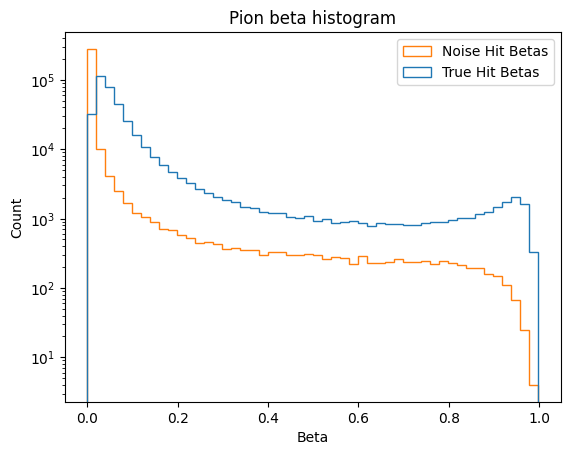

In [ ]:
# Plot the histogram of the true/pred hits for beta values of all hits*events. 

import pickle
import numpy as np
import torch
import glob
import matplotlib.pyplot as plt
from tqdm import tqdm

# NEVER NAME YOUR ANYTHING WITH SPACES PLEASE!!!!!!!!!! 
# ITS A GREAT EVIL!!!!!!!!!!
# dp = __import__("Aggregated Plotting Scripts/data_processing.py")
# from dp import *

# Set file pattern and file limit
particle = "Pion"
file_pattern = f"/users/6/vadna042/hgcalml/hgcal_minimal_eval_example/output/single{particle}_beta_020/*.pkl"
file_limit = 1000

# Load data from pkl files
def load_data(file_path):
    with open(file_path, 'rb') as f:
        data = pickle.load(f)
        score_noise_filter = pickle.load(f)
        pass_noise_filter = pickle.load(f)
        out_gravnet = pickle.load(f)
    return data, score_noise_filter, pass_noise_filter, out_gravnet

# Clustering algorithm from plots3D.
def get_clustering(beta, X, threshold_beta=0.20, threshold_dist=0.5):
    """Cluster points based on beta values and distances."""
    n_points = beta.shape[0]
    select_condpoints = beta > threshold_beta
    indices_condpoints = np.nonzero(select_condpoints)[0]
    indices_condpoints = indices_condpoints[np.argsort(-beta[select_condpoints])]
    unassigned = np.arange(n_points)
    clustering = -1 * np.ones(n_points, dtype=np.int32)
    
    for index_condpoint in indices_condpoints:
        d = np.linalg.norm(X[unassigned] - X[index_condpoint], axis=-1)
        assigned_to_this_condpoint = unassigned[d < threshold_dist]
        clustering[assigned_to_this_condpoint] = index_condpoint
        unassigned = unassigned[~(d < threshold_dist)]
    
    return clustering

# Parsing true input.
def process_data(data):
    true_energies = data.x[:, 0].numpy()
    true_clusters = data.y.numpy()
    return true_energies, true_clusters

# Parsing network output.
def process_gravnet(pass_noise_filter, out_gravnet, cutoff=True):
    """Process the network output to predict clusters."""
    sigmoid = lambda x : (1+np.exp(-x)) ** (-1)
    beta = np.array(sigmoid(out_gravnet[:, 0]))
    cluster_space_coords = out_gravnet[:, 1:].numpy()
    pred_clusters_pnf = get_clustering(beta, cluster_space_coords, threshold_beta=0.2, threshold_dist=0.5)
    pred_clusters = np.zeros_like(pass_noise_filter, dtype=np.int32)
    pred_clusters[pass_noise_filter] = pred_clusters_pnf
    
    unique, counts = np.unique(pred_clusters, return_counts=True)
    cluster_counts = dict(zip(unique, counts))
    if cutoff:
        final_pred_hits = np.array([cluster if cluster_counts[cluster] >= 100 else -2 for cluster in pred_clusters])
    else:
        final_pred_hits = np.array(pred_clusters)

    return final_pred_hits

def main():
    files = glob.glob(file_pattern)[:file_limit]

    tHit_betas = []
    tNoise_betas = []

    for file_path in tqdm(files):
        data, score_noise_filter, pass_noise_filter, out_gravnet = load_data(file_path)
        true_energies, true_clusters = process_data(data)
        pred_clusters = process_gravnet(pass_noise_filter, out_gravnet, cutoff=False)
        
        # print(out_gravnet)
        sigmoid = lambda x : (1+np.exp(-x)) ** (-1)
        beta = np.asarray(sigmoid(out_gravnet[:,0]))
        tHit_betas.append(beta[true_clusters[np.asarray(pass_noise_filter)]==1])

        tNoise_betas.append(beta[true_clusters[np.asarray(pass_noise_filter)]==0])

    tHit_betas = np.concatenate(np.asarray(tHit_betas, dtype=object))
    tNoise_betas = np.concatenate(np.asarray(tNoise_betas, dtype=object))
    plt.hist([tHit_betas, tNoise_betas], histtype="step", bins=50, label=["True Hit Betas","Noise Hit Betas"])
    plt.title(f"{particle} beta histogram")
    plt.xlabel("Beta")
    plt.ylabel("Count")
    plt.yscale("log")
    plt.legend()

if __name__ == '__main__':
    main()

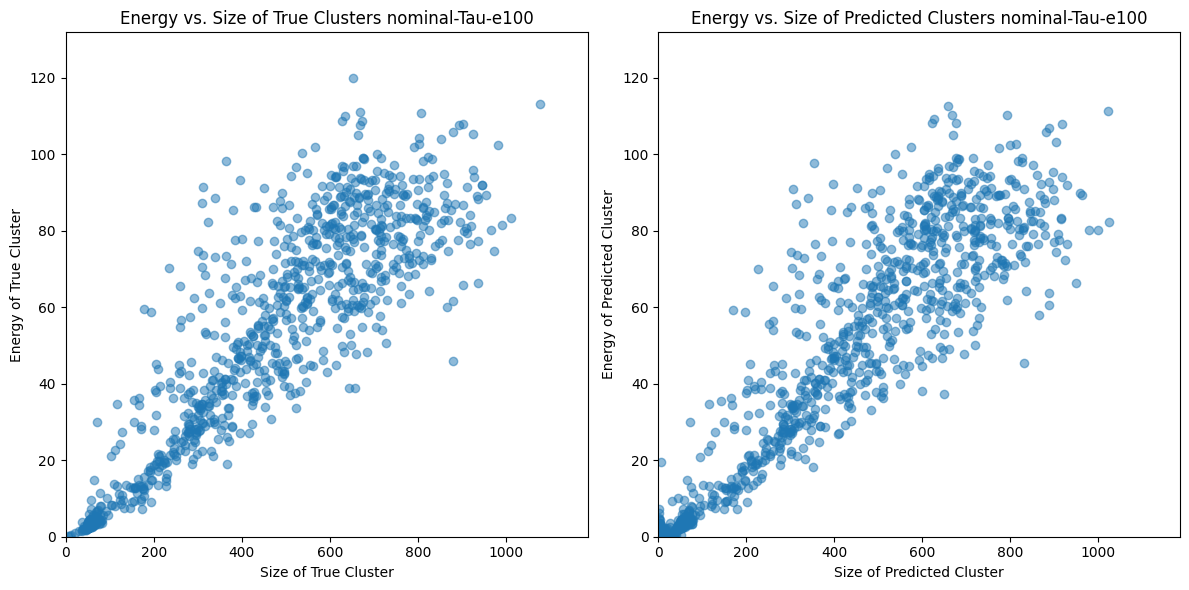

In [9]:
# ENERGY PER PREDICTED AND TRUE CLUSTER

import pickle
import numpy as np
import torch
import matplotlib.pyplot as plt
import AggregatedPlottingScripts.data_processing as dp

# Set file pattern and file limit
# file_pattern = r'C:\Users\tsoli\OneDrive\Documents\School\1 - University of Minnesota\Year 17\Year 1 Research\picklefiles\photons\*.pkl'
# file_pattern = "~/airobustness"

file_limit = 1000

# Clustering algorithm from plots3D.
def get_clustering(beta, X, threshold_beta=0.2, threshold_dist=0.5):
    n_points = beta.shape[0]
    select_condpoints = beta > threshold_beta
    indices_condpoints = np.nonzero(select_condpoints)[0]
    indices_condpoints = indices_condpoints[np.argsort(-beta[select_condpoints])]
    unassigned = np.arange(n_points)
    clustering = -1 * np.ones(n_points, dtype=np.int32)
    
    for index_condpoint in indices_condpoints:
        d = np.linalg.norm(X[unassigned] - X[index_condpoint], axis=-1)
        assigned_to_this_condpoint = unassigned[d < threshold_dist]
        clustering[assigned_to_this_condpoint] = index_condpoint
        unassigned = unassigned[~(d < threshold_dist)]
    
    return clustering

# Parsing true input.
def process_data(data):
    true_energies = data.x[:, 0].numpy()
    true_clusters = data.y.numpy()
    return true_energies, true_clusters


def main():
    # files = glob.glob(file_pattern)[:file_limit]
    species = "Tau"
    sample = "nominal"
    ptdEn = "e100"

    pred_cluster_energies = []
    pred_cluster_sizes = []
    true_cluster_energies = []
    true_cluster_sizes = []

    data_all, pass_noise_filter_all, out_gravnet_all = dp.load_data_bulk(sample, ptdEn, species)

    for event in range(file_limit):
        data = data_all[event]
        pass_noise_filter = pass_noise_filter_all[event]
        out_gravnet = out_gravnet_all[event]
        true_energies, true_clusters = process_data(data)
        pred_clusters = dp.process_gravnet(pass_noise_filter, out_gravnet)
        
        # Calculate energy and size per predicted cluster
        unique_pred_clusters = np.unique(pred_clusters[(pred_clusters > 0)])
        for cluster in unique_pred_clusters:
            cluster_energy = np.sum(true_energies[pred_clusters == cluster])
            cluster_size = np.sum(pred_clusters == cluster)
            pred_cluster_energies.append(cluster_energy)
            pred_cluster_sizes.append(cluster_size)
        
        # Calculate energy and size per true cluster
        unique_true_clusters = np.unique(true_clusters[(true_clusters > 0)])
        for cluster in unique_true_clusters:
            cluster_energy = np.sum(true_energies[true_clusters == cluster])
            cluster_size = np.sum(true_clusters == cluster)
            true_cluster_energies.append(cluster_energy)
            true_cluster_sizes.append(cluster_size)

    # Determine the common x and y ranges
    all_sizes = np.array(true_cluster_sizes + pred_cluster_sizes)
    all_energies = np.array(true_cluster_energies + pred_cluster_energies)
    
    x_min, x_max = all_sizes.min(), all_sizes.max()
    y_min, y_max = all_energies.min(), all_energies.max()
    
    x_range = (0 - 0.05 * abs(x_min), x_max + 0.1 * abs(x_max))
    y_range = (0 - 0.05 * abs(y_min), y_max + 0.1 * abs(y_max))

    # Plot scatter plots
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.scatter(true_cluster_sizes, true_cluster_energies, alpha=0.5)
    plt.xlabel('Size of True Cluster')
    plt.ylabel('Energy of True Cluster')
    plt.title(f'Energy vs. Size of True Clusters {sample}-{species}-{ptdEn}')
    plt.xlim(x_range)
    plt.ylim(y_range)

    plt.subplot(1, 2, 2)
    plt.scatter(pred_cluster_sizes, pred_cluster_energies, alpha=0.5)
    plt.xlabel('Size of Predicted Cluster')
    plt.ylabel('Energy of Predicted Cluster')
    plt.title(f'Energy vs. Size of Predicted Clusters {sample}-{species}-{ptdEn}')
    plt.xlim(x_range)
    plt.ylim(y_range)
    
    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    main()